# import all file that require

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# import file (heart-disease-dataset.zip)

In [7]:
df = pd.read_csv(r"D:/dataset/heart-disease-dataset.zip")

# Display the first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Define Features and Target

In [22]:
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split and Scaling

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 1. Train a Decision Tree Classifier & Visualize

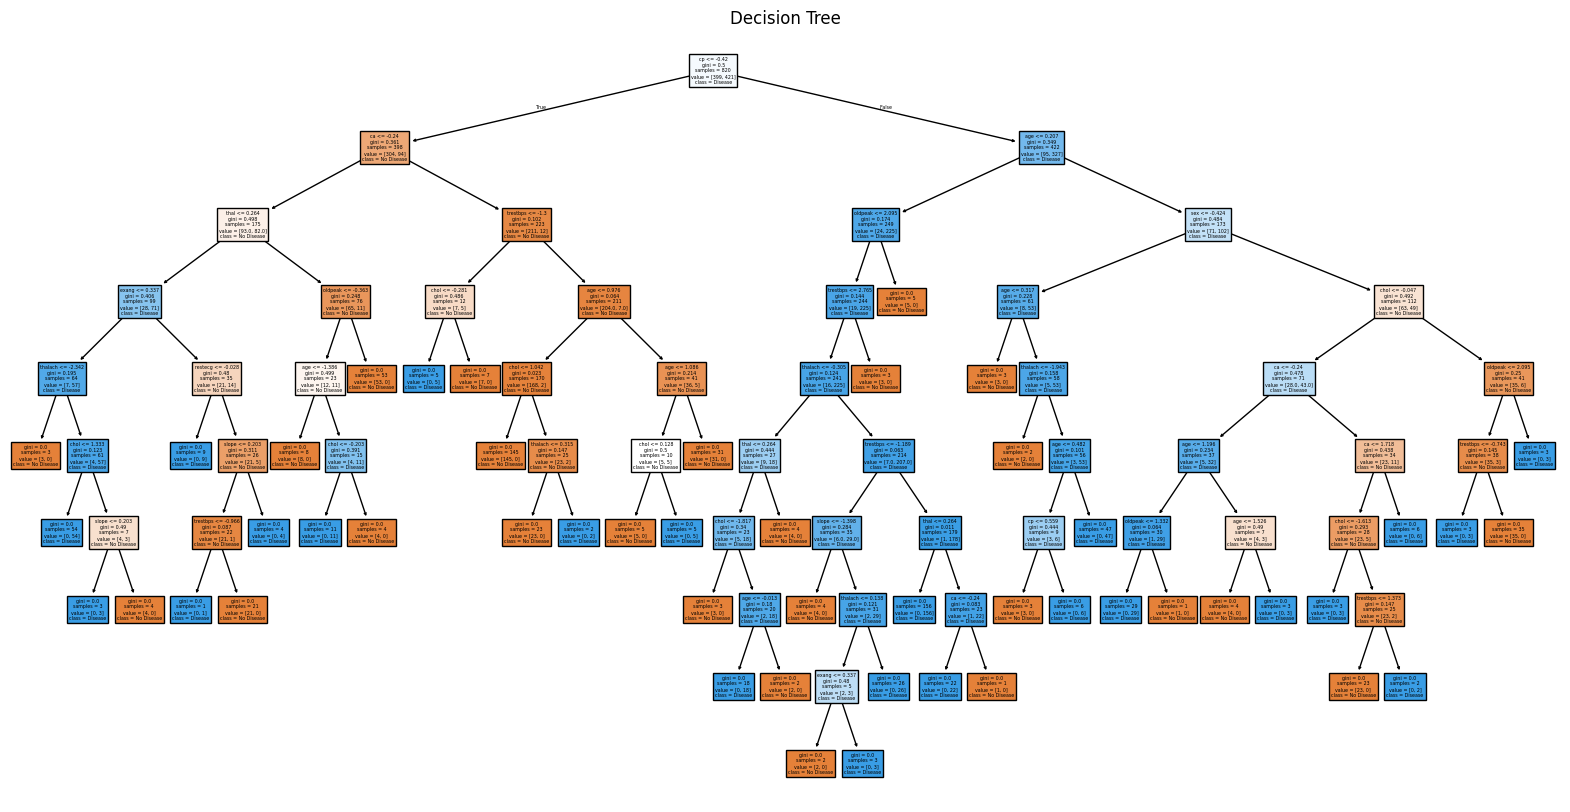

In [11]:
model_dt = DecisionTreeClassifier(max_depth=None, random_state=42)
model_dt.fit(X_train, y_train)

# Visualize tree
plt.figure(figsize=(20, 10))
plot_tree(model_dt, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True)
plt.title("Decision Tree")
plt.show()

# 2. Evaluation

In [12]:
y_pred_dt = model_dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



# 3. Control Overfitting with max_depth

In [23]:
model_dt_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
model_dt_pruned.fit(X_train, y_train)

y_pred_pruned = model_dt_pruned.predict(X_test)
print("Pruned Tree Accuracy:", accuracy_score(y_test, y_pred_pruned))

Pruned Tree Accuracy: 0.8390243902439024


# 4. Train a Random Forest and Compare

In [14]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


# 5. Feature Importance

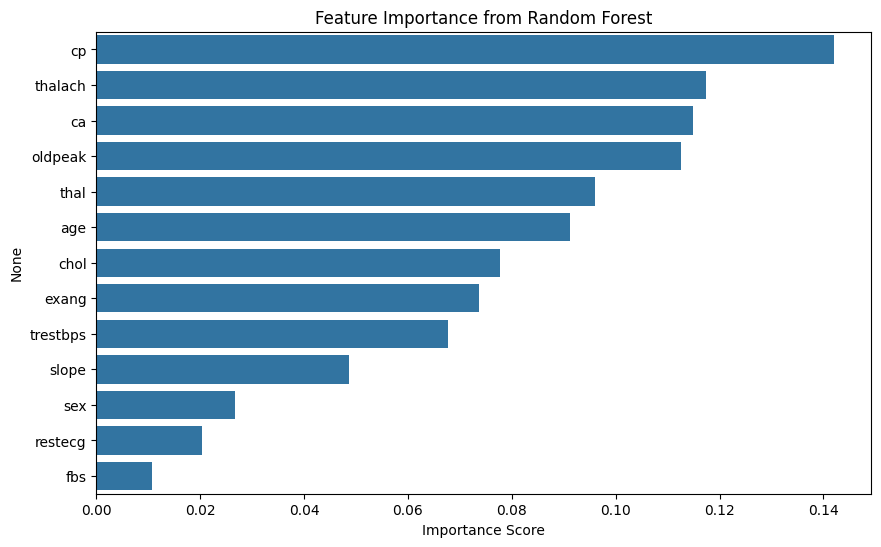

In [24]:
importances = model_rf.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.show()


# 6. Cross-Validation (Random Forest)

In [16]:
cv_scores = cross_val_score(model_rf, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross-validation scores: [1.         1.         1.         1.         0.98536585]
Average CV Accuracy: 0.9970731707317073


# 7. Visualize Decision Boundaries (2D Features)

C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


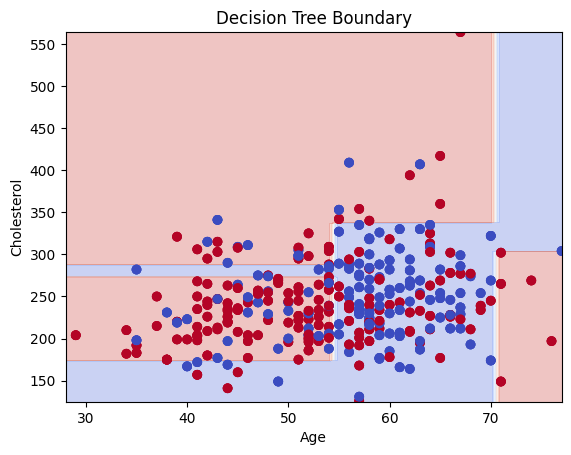

In [17]:
# Pick only 2 numeric features (e.g., age and cholesterol)
X_plot = df[['age', 'chol']]
y_plot = df['target']  # 0 = no disease, 1 = disease

# Train a small decision tree
tree_model = DecisionTreeClassifier(max_depth=3).fit(X_plot, y_plot)

# Create meshgrid for plotting
x_min, x_max = X_plot.iloc[:, 0].min()-1, X_plot.iloc[:, 0].max()+1
y_min, y_max = X_plot.iloc[:, 1].min()-1, X_plot.iloc[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 1),
                     np.arange(y_min, y_max, 1))

Z = tree_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_plot.iloc[:, 0], X_plot.iloc[:, 1], c=y_plot, cmap='coolwarm')
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("Decision Tree Boundary")
plt.show()


# 8. Plot Overfitting with Tree Depth

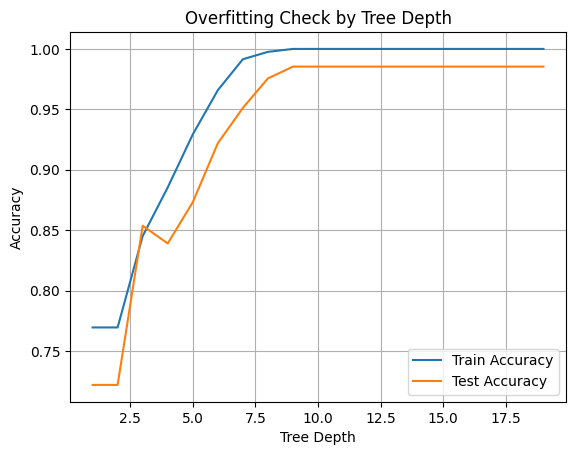

In [20]:
train_acc = []
test_acc = []
depths = range(1, 20)

for d in depths:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Check by Tree Depth")
plt.legend()
plt.grid(True)
plt.show()
